## torch.nn.utils.clip_grad_norm_(self.policy.parameters(),1.0)

这行代码是深度学习训练中防止“梯度爆炸”（Gradient Explosion）的“安全阀”。
简单来说，它的作用是：限制模型参数更新的“步长”，防止模型因为一次更新幅度太大而“学偏了”或导致数值溢出（NaN）。

### 代码拆解

torch.nn.utils.clip_grad_norm_(self.policy.parameters(), 1.0)

1. torch.nn.utils.clip_grad_norm_:
- 这是 PyTorch 提供的一个实用工具函数。
- 注意末尾的下划线 _，这表示它是一个原地操作（in-place operation），会直接修改模型参数的梯度数据，而不是返回一个新的对象。

2. self.policy.parameters():
- 这是你的模型对象（这里叫 policy，通常用于强化学习或生成式模型）。
- .parameters() 会获取模型中所有需要训练的参数（即权重和偏置）。这相当于告诉函数：“请检查这个模型里的每一个参数，不要漏掉任何一个。”

3. 1.0 (max_norm):
- 这是梯度的最大范数阈值。
- 你可以把它理解为“最大允许的步长”。
- 如果计算出的总梯度范数超过 1.0，系统就会按比例缩小梯度，使其范数刚好等于 1.0；如果没超过，则保持不变。

###  核心原理：它是怎么工作的？

在反向传播（loss.backward()）之后，模型会计算出每个参数的梯度。我们可以把所有参数的梯度想象成一个巨大的向量 ⃗g

这个函数会执行以下数学操作：

In [2]:
from IPython.display import Image

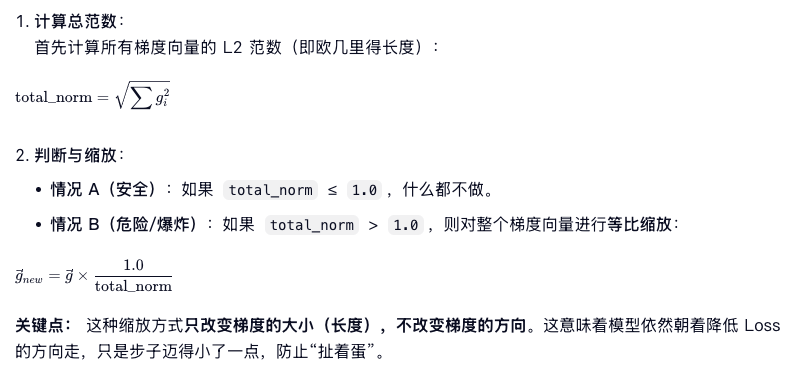

In [3]:
Image(filename='./clip_grad_norm_.png')

## ⚠️ 使用时的关键细节

### 插入位置：
必须放在 loss.backward() 之后，optimizer.step() 之前。

In [ ]:
loss.backward()                  # 1. 计算梯度
# 在这里进行裁剪，防止梯度太大
torch.nn.utils.clip_grad_norm_(...) 
optimizer.step()                 # 2. 使用裁剪后的梯度更新参数

### 混合精度训练（AMP）陷阱：
如果你使用了 GradScaler（混合精度训练），必须先调用 scaler.unscale_(optimizer)，再调用梯度裁剪。否则你会基于被放大的梯度进行裁剪，导致裁剪过度或失效。

### 阈值选择：
1.0 是一个非常通用的经验值，特别适用于 RNN、LSTM 和 Transformer 类模型。对于某些特定的 CNN 模型，这个值可能需要调整（比如 5.0 或 0.5），具体取决于梯度的实际分布。